In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np 
import nltk
import re
from nltk.tokenize import word_tokenize
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
from collections import Counter

import torch
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:

# Load data
train_df = pd.read_csv("../../data/humor/train.csv")
val_df = pd.read_csv("../../data/humor/val.csv")

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Example:", train_df.iloc[0])


Train size: 2360
Validation size: 295
Example: Sentence    Jyotiraditya Scindia is like "Rassi jal gayee ...
Tag                                                         1
Name: 0, dtype: object


In [3]:


def clean_text(x):
    x = re.sub(r'http\S+|www\S+|https\S+', '', str(x))
    x = re.sub(r'\s+', ' ', x)
    x = re.sub(r'[^a-zA-Z0-9\s]', '', x)
    x = re.sub(r'\d+', '', x)
    x = re.sub(r'[^\w\s]', '', x)
    x = re.sub(r'#', '', x)
    x = re.sub(r'\s+', ' ', x)
    x = x.strip()
    x = x.lower()
    return x

train_df['Sentence'] = train_df['Sentence'].apply(clean_text)

In [4]:
vocab = Counter(word for sentence in train_df['Sentence'] for word in sentence.split())
word2idx = {word: i for i, (word, _) in enumerate(vocab.items())}
idx2word = {i: word for word, i in word2idx.items()}
vocab_size = len(word2idx)
print("Vocabulary size:", vocab_size)

Vocabulary size: 7179


In [6]:
class HumorDataset(Dataset):
    def __init__(self, df, word2idx, max_len=100):
        self.sentences = df["Sentence"].tolist()
        self.labels = df["Tag"].tolist()
        self.word2idx = word2idx
        self.max_len = max_len

    def encode(self, sentence):
        tokens = sentence.lower().split()
        # Use word2idx directly without <UNK>
        ids = [self.word2idx.get(tok, 0) for tok in tokens]  # Use 0 (pad index) for unknown tokens
        ids = ids[:self.max_len]  # Truncate to max_len
        ids += [0] * (self.max_len - len(ids))  # Pad with 0 (assuming 0 is the padding index)
        return torch.tensor(ids)

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        return self.encode(self.sentences[idx]), torch.tensor(self.labels[idx], dtype=torch.float)

# Create datasets and dataloaders
train_dataset = HumorDataset(train_df, word2idx)
val_dataset = HumorDataset(val_df, word2idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)


# `Importing pretrained embeddings from previous assignment`

In [8]:
embedding_matrix = np.load('../../Word2Vec/models/word2vec/humor/word_embeddings_100epochs_cleantext.npy', allow_pickle=True).item()
embedding_matrix = np.array(list(embedding_matrix.values()))  # Extract embeddings as a NumPy array

pretrained_embeddings = torch.tensor(embedding_matrix, dtype=torch.float32)

# `RNN Classifier`

In [9]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=64, pretrained_embeddings=None):
        super().__init__()
        embed_dim = pretrained_embeddings.shape[1]
        self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings, freeze=False)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True, nonlinearity='relu')
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.embedding(x)
        _, h_n = self.rnn(x)
        x = h_n.squeeze(0)
        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        return self.fc2(x).squeeze(1)


In [16]:
def train(model, train_loader, val_loader, num_epochs, model_name):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.cuda()
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-6)

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.cuda(), labels.cuda()
            # print(inputs.device, labels.device, model.device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(train_loader):.4f}")

    # Save the trained model
    torch.save(model.state_dict(), f"{model_name}.pt")
    print(f"Model saved as {model_name}.pt")

    # Evaluate
    evaluate(model, val_loader)

def evaluate(model, val_loader):
    model.eval()
    correct = 0
    total = 0
    device = next(model.parameters()).device
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.cuda(), labels.cuda()
            outputs = torch.sigmoid(model(inputs))
            preds = (outputs > 0.5).int()
            correct += (preds == labels.int()).sum().item()
            total += labels.size(0)
    acc = correct / total * 100
    print(f"Validation Accuracy: {acc:.2f}%")


In [ ]:
"""
MODEL TRAINING CODE

rnn_model = RNNClassifier(vocab_size=vocab_size, pretrained_embeddings=pretrained_embeddings)
train(rnn_model, train_loader, val_loader, num_epochs=50, model_name="rnn_model")


"""



Epoch 1/50, Loss: 0.7133
Epoch 2/50, Loss: 0.7127
Epoch 3/50, Loss: 0.7111
Epoch 4/50, Loss: 0.7121
Epoch 5/50, Loss: 0.7107
Epoch 6/50, Loss: 0.7092
Epoch 7/50, Loss: 0.7106
Epoch 8/50, Loss: 0.7082
Epoch 9/50, Loss: 0.7092
Epoch 10/50, Loss: 0.7076
Epoch 11/50, Loss: 0.7073
Epoch 12/50, Loss: 0.7056
Epoch 13/50, Loss: 0.7071
Epoch 14/50, Loss: 0.7053
Epoch 15/50, Loss: 0.7051
Epoch 16/50, Loss: 0.7035
Epoch 17/50, Loss: 0.7025
Epoch 18/50, Loss: 0.7024
Epoch 19/50, Loss: 0.7031
Epoch 20/50, Loss: 0.7021
Epoch 21/50, Loss: 0.7010
Epoch 22/50, Loss: 0.6999
Epoch 23/50, Loss: 0.7005
Epoch 24/50, Loss: 0.7004
Epoch 25/50, Loss: 0.6989
Epoch 26/50, Loss: 0.6984
Epoch 27/50, Loss: 0.6985
Epoch 28/50, Loss: 0.6989
Epoch 29/50, Loss: 0.6978
Epoch 30/50, Loss: 0.6972
Epoch 31/50, Loss: 0.6959
Epoch 32/50, Loss: 0.6966
Epoch 33/50, Loss: 0.6959
Epoch 34/50, Loss: 0.6961
Epoch 35/50, Loss: 0.6956
Epoch 36/50, Loss: 0.6953
Epoch 37/50, Loss: 0.6947
Epoch 38/50, Loss: 0.6959
Epoch 39/50, Loss: 0.

In [18]:
# Load the saved model
rnn_model = RNNClassifier(vocab_size=vocab_size, pretrained_embeddings=pretrained_embeddings)
rnn_model.load_state_dict(torch.load("rnn_model.pt"))
rnn_model.eval()


RNNClassifier(
  (embedding): Embedding(7179, 100)
  (rnn): RNN(100, 64, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)

In [19]:
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = rnn_model(inputs)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.4).long()
        
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())


In [ ]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, digits=4, target_names=["humor", "non-humor"]))


Classification Report:

              precision    recall  f1-score   support

        Hate     0.0000    0.0000    0.0000       119
    Non-Hate     0.5966    1.0000    0.7473       176

    accuracy                         0.5966       295
   macro avg     0.2983    0.5000    0.3737       295
weighted avg     0.3559    0.5966    0.4459       295



/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

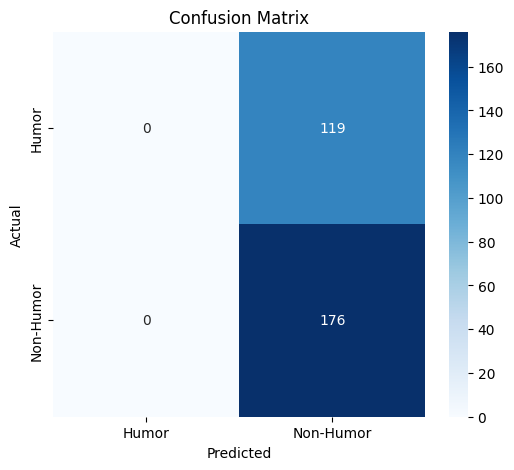

In [22]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=["Humor", "Non-Humor"], yticklabels=["Humor", "Non-Humor"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# `LSTM Classifier`

In [23]:

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128, num_layers=2, pretrained_embeddings=None):
        super().__init__()

        embed_dim = pretrained_embeddings.shape[1]

        self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings, freeze=False, padding_idx=0)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False,
            dropout=0.3 if num_layers > 1 else 0.0  # Only applies if num_layers > 1
        )

        self.dropout = nn.Dropout(0.5)
        self.layernorm = nn.LayerNorm(hidden_dim)
        self.fc1 = nn.Linear(hidden_dim, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.embedding(x)                             # [batch, seq, embed]
        _, (h_n, _) = self.lstm(x)                         # h_n: [num_layers, batch, hidden]
        x = h_n[-1]                                        # Take output of the top LSTM layer
        x = self.layernorm(x)
        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        return self.fc2(x).squeeze(1)       

In [ ]:
"""
MODEL TRAINING CODE

lstm_model = LSTMClassifier(vocab_size=vocab_size, pretrained_embeddings=pretrained_embeddings)
train(lstm_model, train_loader, val_loader, num_epochs=50, model_name="lstm_model_50epoch")



"""


Epoch 1/50, Loss: 0.7374
Epoch 2/50, Loss: 0.7283
Epoch 3/50, Loss: 0.7199
Epoch 4/50, Loss: 0.7106
Epoch 5/50, Loss: 0.7107
Epoch 6/50, Loss: 0.7095
Epoch 7/50, Loss: 0.7017
Epoch 8/50, Loss: 0.6997
Epoch 9/50, Loss: 0.6984
Epoch 10/50, Loss: 0.6937
Epoch 11/50, Loss: 0.6934
Epoch 12/50, Loss: 0.6809
Epoch 13/50, Loss: 0.6902
Epoch 14/50, Loss: 0.6861
Epoch 15/50, Loss: 0.6836
Epoch 16/50, Loss: 0.6838
Epoch 17/50, Loss: 0.6889
Epoch 18/50, Loss: 0.6817
Epoch 19/50, Loss: 0.6846
Epoch 20/50, Loss: 0.6860
Epoch 21/50, Loss: 0.6865
Epoch 22/50, Loss: 0.6784
Epoch 23/50, Loss: 0.6831
Epoch 24/50, Loss: 0.6834
Epoch 25/50, Loss: 0.6910
Epoch 26/50, Loss: 0.6832
Epoch 27/50, Loss: 0.6806
Epoch 28/50, Loss: 0.6806
Epoch 29/50, Loss: 0.6821
Epoch 30/50, Loss: 0.6796
Epoch 31/50, Loss: 0.6836
Epoch 32/50, Loss: 0.6779
Epoch 33/50, Loss: 0.6819
Epoch 34/50, Loss: 0.6788
Epoch 35/50, Loss: 0.6875
Epoch 36/50, Loss: 0.6858
Epoch 37/50, Loss: 0.6845
Epoch 38/50, Loss: 0.6820
Epoch 39/50, Loss: 0.

In [25]:
# Load the saved model
lstm_model = LSTMClassifier(vocab_size=vocab_size, pretrained_embeddings=pretrained_embeddings)
lstm_model.load_state_dict(torch.load("lstm_model_50epoch.pt"))
lstm_model.eval()


LSTMClassifier(
  (embedding): Embedding(7179, 100, padding_idx=0)
  (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.5, inplace=False)
  (layernorm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)

In [26]:
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = lstm_model(inputs)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.4).long()
        
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())


In [27]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, digits=4, target_names=["Humor", "Non-Humor"]))


Classification Report:

              precision    recall  f1-score   support

       Humor     0.0000    0.0000    0.0000       119
   Non-Humor     0.5966    1.0000    0.7473       176

    accuracy                         0.5966       295
   macro avg     0.2983    0.5000    0.3737       295
weighted avg     0.3559    0.5966    0.4459       295



/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

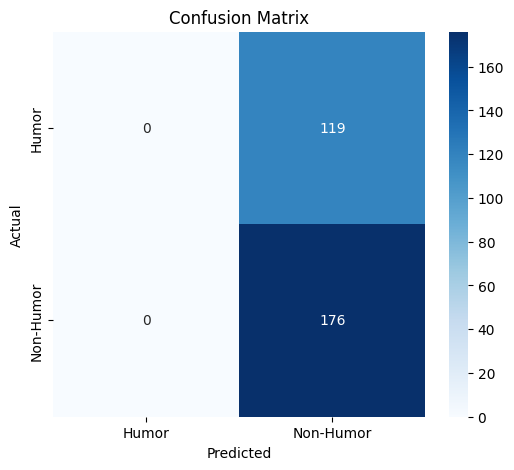

In [28]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=["Humor", "Non-Humor"], yticklabels=["Humor", "Non-Humor"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# `Transformer`

In [29]:
import math
import torch.nn as nn
import torch

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # [1, max_len, d_model]
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return x


In [30]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_heads=4, num_layers=2, ff_dim=256, dropout=0.1, pretrained_embeddings=None, max_len=5000):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings, freeze=False)
        self.pos_encoder = PositionalEncoding(embed_dim, max_len)
        encoder_layer = nn.TransformerEncoderLayer(embed_dim, num_heads, ff_dim, dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers)
        self.fc = nn.Linear(embed_dim, 1)

    def forward(self, x):
        x = self.embedding(x)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)  # [batch, seq, embed_dim]
        x = x.mean(dim=1)  # Mean pooling over sequence
        return self.fc(x).squeeze(1)


In [ ]:
"""
MODEL TRAINING CODE

transformer_model = TransformerClassifier(vocab_size, embed_dim=100, pretrained_embeddings=pretrained_embeddings)
train(transformer_model, train_loader, val_loader, num_epochs=50, model_name="transformer_model")


"""


Epoch 1/50, Loss: 0.6938
Epoch 2/50, Loss: 0.6845
Epoch 3/50, Loss: 0.6782
Epoch 4/50, Loss: 0.6740
Epoch 5/50, Loss: 0.6713
Epoch 6/50, Loss: 0.6695
Epoch 7/50, Loss: 0.6680
Epoch 8/50, Loss: 0.6671
Epoch 9/50, Loss: 0.6670
Epoch 10/50, Loss: 0.6661
Epoch 11/50, Loss: 0.6653
Epoch 12/50, Loss: 0.6650
Epoch 13/50, Loss: 0.6643
Epoch 14/50, Loss: 0.6638
Epoch 15/50, Loss: 0.6632
Epoch 16/50, Loss: 0.6624
Epoch 17/50, Loss: 0.6619
Epoch 18/50, Loss: 0.6614
Epoch 19/50, Loss: 0.6609
Epoch 20/50, Loss: 0.6601
Epoch 21/50, Loss: 0.6597
Epoch 22/50, Loss: 0.6591
Epoch 23/50, Loss: 0.6587
Epoch 24/50, Loss: 0.6575
Epoch 25/50, Loss: 0.6571
Epoch 26/50, Loss: 0.6563
Epoch 27/50, Loss: 0.6555
Epoch 28/50, Loss: 0.6550
Epoch 29/50, Loss: 0.6543
Epoch 30/50, Loss: 0.6536
Epoch 31/50, Loss: 0.6531
Epoch 32/50, Loss: 0.6520
Epoch 33/50, Loss: 0.6512
Epoch 34/50, Loss: 0.6506
Epoch 35/50, Loss: 0.6504
Epoch 36/50, Loss: 0.6495
Epoch 37/50, Loss: 0.6486
Epoch 38/50, Loss: 0.6477
Epoch 39/50, Loss: 0.

Classification Report:

              precision    recall  f1-score   support

        Hate     0.0000    0.0000    0.0000       119
    Non-Hate     0.5966    1.0000    0.7473       176

    accuracy                         0.5966       295
   macro avg     0.2983    0.5000    0.3737       295
weighted avg     0.3559    0.5966    0.4459       295



/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

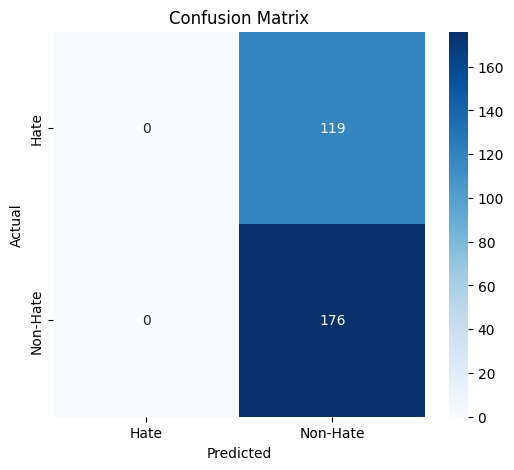

In [ ]:
# Load the saved model
transformer_model = TransformerClassifier(vocab_size=vocab_size, embed_dim=100, pretrained_embeddings=pretrained_embeddings)
transformer_model.load_state_dict(torch.load("transformer_model.pt"))
transformer_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = transformer_model(inputs)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).long()
        
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

print("Classification Report:\n")
print(classification_report(all_labels, all_preds, digits=4, target_names=["humor", "non-humor"]))

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=["humor", "non-humor"], yticklabels=["humor", "non-humor"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# `Bert Transformer`

In [3]:
from transformers import BertTokenizer, BertModel
from torch.utils.data import Dataset

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

class HateDataset(Dataset):
    def __init__(self, sentences, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(sentences, padding=True, truncation=True, max_length=max_length, return_tensors="pt")
        self.labels = torch.tensor(labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)


/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
class BERTDataset(Dataset):
    def __init__(self, data, tokenizer, max_len=128):
        self.sentences = data["Sentence"].tolist()
        self.labels = data["Tag"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self): return len(self.sentences)

    def __getitem__(self, idx):
        encoding = self.tokenizer.encode_plus(
            self.sentences[idx],
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }


In [8]:
class BERTClassifier(nn.Module):
    def __init__(self, output_dim=100):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")

        # 🔒 Freeze all BERT layers
        for param in self.bert.parameters():
            param.requires_grad = False

        # 🔄 Only train this classifier head
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(self.bert.config.hidden_size, output_dim)

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():  # Still allows gradient flow through classifier
            outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.dropout(outputs.pooler_output)
        return self.fc(pooled)


In [11]:

output_dim = len(set(train_df["Tag"]))
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

bert_model = BERTClassifier(output_dim=output_dim)
val_bert_loader = DataLoader(BERTDataset(val_df, tokenizer), batch_size=512)

# BERT model Training
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_bert_loader = DataLoader(BERTDataset(train_df, tokenizer), batch_size=512, shuffle=True)
bert_model = BERTClassifier(output_dim=output_dim).to(device)
optimizer = optim.Adam(bert_model.parameters(), lr=2e-4)
criterion = nn.CrossEntropyLoss()

In [ ]:
# for epoch in range(50):
#         bert_model.train()
#         total_loss = 0
#         for batch in train_bert_loader:
#             input_ids = batch['input_ids'].to(device)
#             mask = batch['attention_mask'].to(device)
#             labels = batch['label'].to(device)

#             optimizer.zero_grad()
#             outputs = bert_model(input_ids, mask)
#             loss = criterion(outputs, labels)
#             loss.backward()
#             optimizer.step()
#             total_loss += loss.item()
#         print(f"[BERT Epoch {epoch+1}] Loss: {total_loss:.4f}")

# torch.save(bert_model.fc.state_dict(), f"BERT_50epoch.pth")

[BERT Epoch 1] Loss: 3.5060
[BERT Epoch 2] Loss: 3.4848
[BERT Epoch 3] Loss: 3.4485
[BERT Epoch 4] Loss: 3.4436
[BERT Epoch 5] Loss: 3.4454
[BERT Epoch 6] Loss: 3.4252
[BERT Epoch 7] Loss: 3.4115
[BERT Epoch 8] Loss: 3.3956
[BERT Epoch 9] Loss: 3.4278
[BERT Epoch 10] Loss: 3.3756
[BERT Epoch 11] Loss: 3.4229
[BERT Epoch 12] Loss: 3.3624
[BERT Epoch 13] Loss: 3.3955
[BERT Epoch 14] Loss: 3.3550
[BERT Epoch 15] Loss: 3.3666
[BERT Epoch 16] Loss: 3.3524
[BERT Epoch 17] Loss: 3.3288
[BERT Epoch 18] Loss: 3.3550


In [ ]:
bert_model.fc.load_state_dict(torch.load(f"BERT_50epoch.pth", map_location=device))


<All keys matched successfully>

/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

              precision    recall  f1-score   support

        hate     0.9029    1.0000    0.9489       474
    non-hate     0.0000    0.0000    0.0000        51

    accuracy                         0.9029       525
   macro avg     0.4514    0.5000    0.4745       525
weighted avg     0.8152    0.9029    0.8568       525



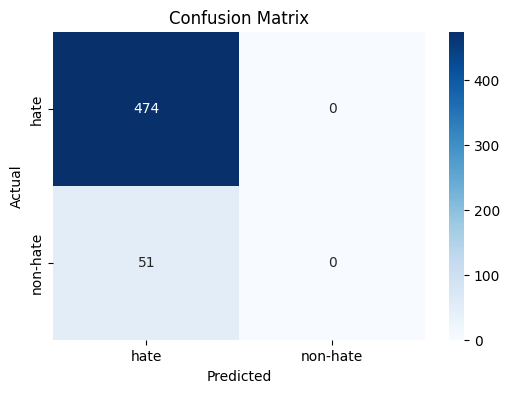

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Make sure model is on the right device and in eval mode
bert_model.eval()
bert_model.to(device)

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_bert_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = bert_model(input_ids, attention_mask)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 🎯 Classification report
print(classification_report(all_labels, all_preds, target_names=["humor", "non-humor"], digits=4))

# 📊 Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["humor", "non-humor"], yticklabels=["humor", "non-humor"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
